# CARS Spectroscopy Temperature Inversion

This notebook demonstrates the end-to-end pipeline for recovering gas temperature from a synthetic N2 coherent anti-Stokes Raman scattering (CARS) spectrum.

**Pipeline stages:**
1. Load precomputed data and reference outputs
2. Visualize the ground truth and noisy measurement
3. Show the inversion result (precomputed)
4. Evaluate metrics

The results are loaded from `evaluation/reference_outputs/` so this notebook runs in seconds.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Load Data

In [2]:
data_dir = os.path.join('..', 'data')
ref_dir = os.path.join('..', 'evaluation', 'reference_outputs')

raw = np.load(os.path.join(data_dir, 'raw_data.npz'))
gt = np.load(os.path.join(data_dir, 'ground_truth.npz'))
recon = np.load(os.path.join(ref_dir, 'reconstruction.npz'))

measurements = raw['measurements'][0]
nu_axis = raw['nu_axis'][0]
gt_spectrum = gt['spectrum'][0]
gt_temperature = float(gt['temperature'][0])

y_pred = recon['y_pred'][0]
T_pred = float(recon['temperature_pred'][0])

print(f"Wavenumber range: {nu_axis[0]:.1f} - {nu_axis[-1]:.1f} cm-1 ({len(nu_axis)} points)")
print(f"Ground truth temperature: {gt_temperature:.0f} K")
print(f"Predicted temperature: {T_pred:.1f} K")

Wavenumber range: 2280.0 - 2330.0 cm-1 (200 points)
Ground truth temperature: 2400 K
Predicted temperature: 2391.6 K


## 2. Visualize Ground Truth vs Measurement

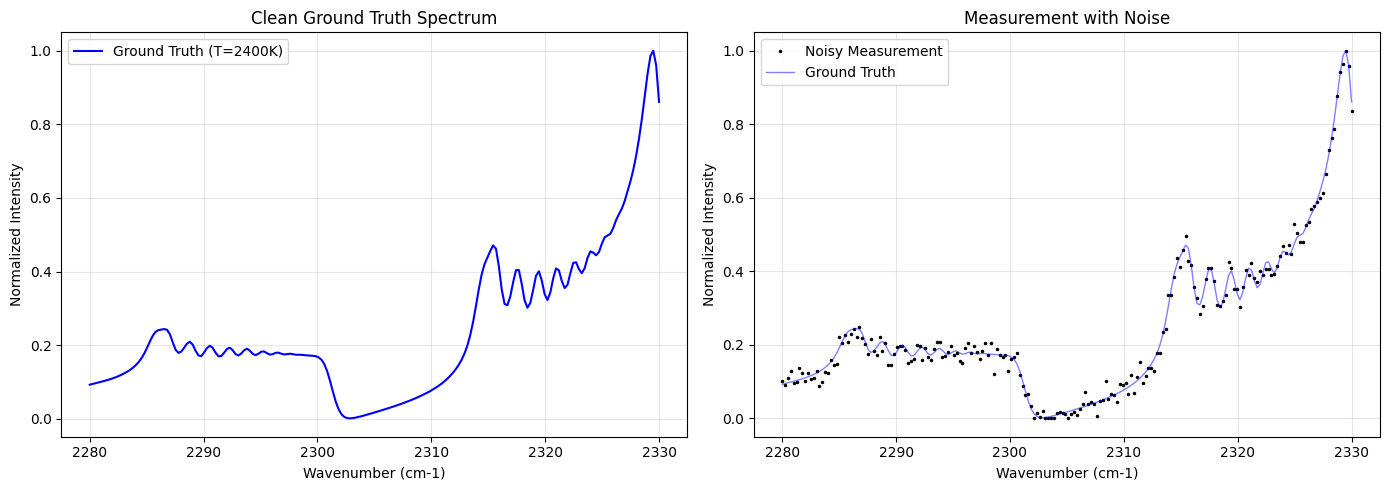

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(nu_axis, gt_spectrum, 'b-', linewidth=1.5, label=f'Ground Truth (T={gt_temperature:.0f}K)')
axes[0].set_xlabel('Wavenumber (cm-1)')
axes[0].set_ylabel('Normalized Intensity')
axes[0].set_title('Clean Ground Truth Spectrum')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(nu_axis, measurements, 'k.', markersize=3, label='Noisy Measurement')
axes[1].plot(nu_axis, gt_spectrum, 'b-', alpha=0.5, linewidth=1, label='Ground Truth')
axes[1].set_xlabel('Wavenumber (cm-1)')
axes[1].set_ylabel('Normalized Intensity')
axes[1].set_title('Measurement with Noise')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Inversion Result

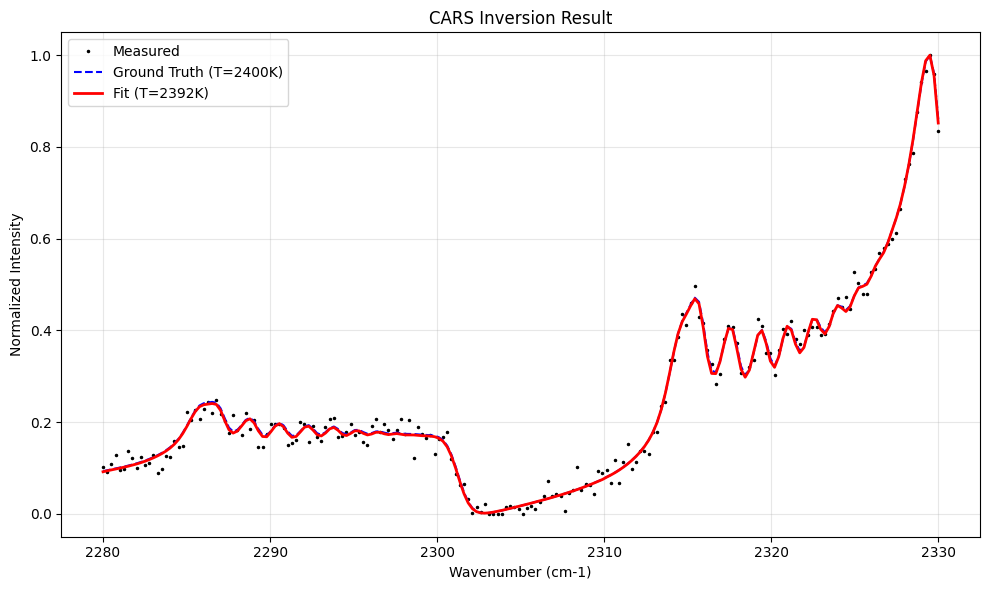

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(nu_axis, measurements, 'k.', markersize=3, label='Measured')
plt.plot(nu_axis, gt_spectrum, 'b--', linewidth=1.5, label=f'Ground Truth (T={gt_temperature:.0f}K)')
plt.plot(nu_axis, y_pred, 'r-', linewidth=2, label=f'Fit (T={T_pred:.0f}K)')
plt.xlabel('Wavenumber (cm-1)')
plt.ylabel('Normalized Intensity')
plt.title('CARS Inversion Result')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Residuals

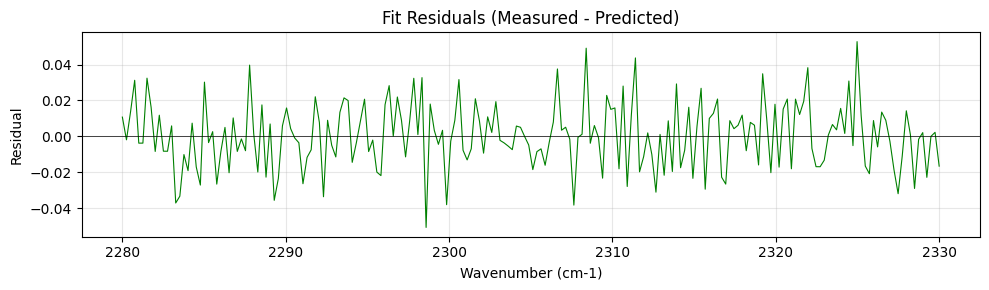

In [5]:
residual = measurements - y_pred

plt.figure(figsize=(10, 3))
plt.plot(nu_axis, residual, 'g-', linewidth=0.8)
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel('Wavenumber (cm-1)')
plt.ylabel('Residual')
plt.title('Fit Residuals (Measured - Predicted)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Metrics

In [6]:
from src.visualization import compute_metrics

metrics = compute_metrics(measurements, y_pred,
                          {'temperature': T_pred},
                          params_true={'temperature': gt_temperature})

print("=" * 45)
print("  CARS Inversion Metrics")
print("=" * 45)
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"  {k:25s}: {v:.6f}")
    else:
        print(f"  {k:25s}: {v}")
print("=" * 45)

  CARS Inversion Metrics
  mse                      : 0.000333
  psnr_dB                  : 34.779548
  ncc                      : 0.998361
  nrmse                    : 0.018240
  temperature_error_K      : 8.435821
  temperature_true_K       : 2400.000000
  temperature_pred_K       : 2391.564179


## 6. Run Full Pipeline from Scratch (Optional)

Uncomment and run the cell below to execute the full inversion pipeline instead of loading precomputed results. This takes about 10-20 seconds.

In [7]:
# from src.preprocessing import load_and_preprocess_data
# from src.solvers import run_inversion
# from src.visualization import plot_inversion_result
#
# processed_signal, nu_proc = load_and_preprocess_data(measurements, nu_axis, noise_level=0.0)
#
# initial_guesses = {
#     'temperature': 2000,
#     'x_mol': 0.79,
#     'pressure': 1.0,
#     'pump_lw': 1.0,
# }
#
# result = run_inversion(processed_signal, nu_proc, initial_guesses)
# print(f"Fitted temperature: {result['best_params']['temperature']:.1f} K")
# print(f"Success: {result['success']}, Cost: {result['cost']:.6e}")